In [ ]:
import cv2
import tensorflow as tf
from tensorflow import keras
import numpy as np
from keras import layers
import os

In [ ]:
# In[57]:


latent_dim=256
height=512
width=512
channels=3

In [ ]:
# In[58]:


generator_input = keras.Input(shape=(latent_dim,))
x = layers.Dense(128 * 64 * 64)(generator_input)
x = layers.LeakyReLU()(x)
x = layers.Reshape((64, 64, 128))(x)
x = layers.Conv2D(256, 5, padding='same')(x)
x = layers.LeakyReLU()(x)
x = layers.Conv2DTranspose(256, 4, strides=2, padding='same')(x)
x = layers.LeakyReLU()(x)
x = layers.Conv2D(256, 5, padding='same')(x)
x = layers.LeakyReLU()(x)
x = layers.Conv2D(256, 5, padding='same')(x)
x = layers.LeakyReLU()(x)

In [ ]:
# In[59]:


x = layers.Conv2D(channels, 7, activation='tanh', padding='same')(x)
generator = keras.models.Model(generator_input, x)
generator.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 256)]             0         
                                                                 
 dense (Dense)               (None, 524288)            134742016 
                                                                 
 leaky_re_lu (LeakyReLU)     (None, 524288)            0         
                                                                 
 reshape (Reshape)           (None, 64, 64, 128)       0         
                                                                 
 conv2d (Conv2D)             (None, 64, 64, 256)       819456    
                                                                 
 leaky_re_lu_1 (LeakyReLU)   (None, 64, 64, 256)       0         
                                                                 
 conv2d_transpose (Conv2DTr  (None, 128, 128, 256)     104883

In [ ]:
# In[60]:


discriminator_input = layers.Input(shape=(height, width, channels))
x = layers.Conv2D(128, 3)(discriminator_input)
x = layers.LeakyReLU()(x)
x = layers.Conv2D(128, 4, strides=2)(x)
x = layers.LeakyReLU()(x)
x = layers.Conv2D(128, 4, strides=2)(x)
x = layers.LeakyReLU()(x)
x = layers.Conv2D(128, 4, strides=2)(x)
x = layers.LeakyReLU()(x)
x = layers.Flatten()(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(1, activation='sigmoid')(x)
discriminator = keras.models.Model(discriminator_input, x)
discriminator.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 512, 512, 3)]     0         
                                                                 
 conv2d_4 (Conv2D)           (None, 510, 510, 128)     3584      
                                                                 
 leaky_re_lu_5 (LeakyReLU)   (None, 510, 510, 128)     0         
                                                                 
 conv2d_5 (Conv2D)           (None, 254, 254, 128)     262272    
                                                                 
 leaky_re_lu_6 (LeakyReLU)   (None, 254, 254, 128)     0         
                                                                 
 conv2d_6 (Conv2D)           (None, 126, 126, 128)     262272    
                                                                 
 leaky_re_lu_7 (LeakyReLU)   (None, 126, 126, 128)     0   

In [ ]:
# In[61]:


discriminator_optimizer = keras.optimizers.legacy.RMSprop(lr=0.0008,clipvalue=1.0,decay=1e-8)
discriminator.compile(optimizer=discriminator_optimizer,loss='binary_crossentropy')

In [ ]:
# In[62]:


discriminator.trainable = False
gan_input = keras.Input(shape=(latent_dim,))
gan_output = discriminator(generator(gan_input))
gan = keras.models.Model(gan_input, gan_output)
gan_optimizer = keras.optimizers.legacy.RMSprop(lr=0.0004, clipvalue=1.0, decay=1e-8)
gan.compile(optimizer=gan_optimizer, loss='binary_crossentropy')

In [ ]:
# In[63]:


import os
from keras.preprocessing import image

In [ ]:
# In[64]:


(x_train, y_train), (_, _) = keras.datasets.cifar10.load_data()

170498071/170498071 [==============================] - 2s 0us/step


In [ ]:
# In[65]:


x_train = x_train[y_train.flatten() == 6]
x_train = x_train.reshape((x_train.shape[0],) +(height, width, channels)).astype('float32') / 255.

In [ ]:
# In[66]:


iterations = 10000
batch_size = 20

save_dir="C:/Users/ahsan/my"

In [ ]:
# In[67]:


start = 0
for step in range(iterations):
    random_latent_vectors = np.random.normal(size=(batch_size,latent_dim))

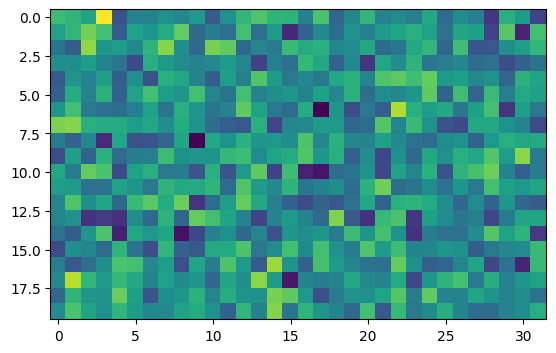

In [ ]:
plt.imshow(random_latent_vectors)

In [ ]:
# In[68]:


generated_images = generator.predict(random_latent_vectors)

1/1 [==============================] - 3s 3s/step


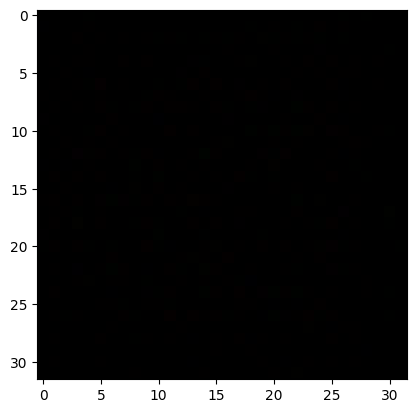

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(generated_images[5])

In [ ]:
# In[69]:


stop = start + batch_size
real_images = x_train[start: stop]
combined_images = np.concatenate([generated_images, real_images])

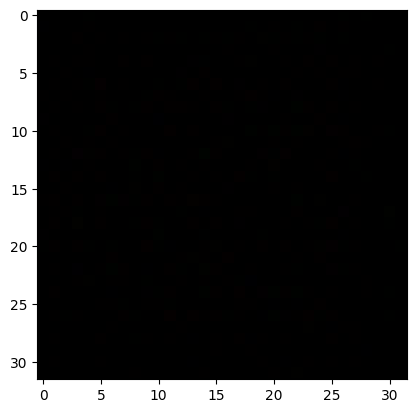

In [ ]:
plt.imshow(combined_images[5])

In [ ]:
# In[70]:


labels = np.concatenate([np.ones((batch_size, 1)),np.zeros((batch_size, 1))])
labels += 0.05 * np.random.random(labels.shape)
d_loss = discriminator.train_on_batch(combined_images, labels)
d_loss = discriminator.train_on_batch(combined_images, labels)
random_latent_vectors = np.random.normal(size=(batch_size,latent_dim))

In [ ]:
d_loss

0.5069056749343872

In [ ]:
labels

array([[1.00259664e+00],
       [1.03590210e+00],
       [1.00370258e+00],
       [1.00485973e+00],
       [1.04399582e+00],
       [1.04444834e+00],
       [1.04727532e+00],
       [1.01211520e+00],
       [1.03746047e+00],
       [1.02497121e+00],
       [1.04882224e+00],
       [1.03428358e+00],
       [1.01380993e+00],
       [1.01816965e+00],
       [1.00022926e+00],
       [1.02164409e+00],
       [1.04320091e+00],
       [1.03209509e+00],
       [1.04147209e+00],
       [1.00155872e+00],
       [2.87145128e-02],
       [4.69399750e-02],
       [2.91893024e-04],
       [1.41565138e-02],
       [2.42879523e-02],
       [1.12519402e-02],
       [3.71140932e-02],
       [1.43101885e-03],
       [1.70077254e-02],
       [1.69269305e-02],
       [4.16883634e-02],
       [1.14319331e-03],
       [1.94441885e-02],
       [3.24460814e-02],
       [1.70627361e-04],
       [3.58898890e-02],
       [4.07262269e-02],
       [5.22767184e-03],
       [3.39825111e-02],
       [1.34729261e-02]])

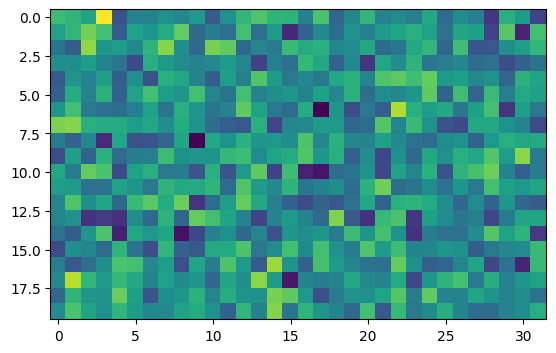

In [ ]:
plt.imshow(random_latent_vectors)

In [ ]:
# In[71]:


misleading_targets = np.zeros((batch_size, 1))

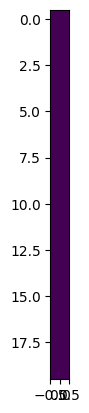

In [ ]:
plt.imshow(misleading_targets)

In [ ]:
# In[72]:


a_loss = gan.train_on_batch(random_latent_vectors,misleading_targets)

In [ ]:
a_loss

0.6916441917419434

In [ ]:
# In[73]:


start += batch_size
if start > len(x_train) - batch_size:
    start = 0

In [ ]:
# In[74]:


if step % 100 == 0:
    gan.save_weights('gan.h5')
    print('discriminator loss:', d_loss)
    print('adversarial loss:', a_loss)
    img = image.array_to_img(generated_images[0] * 255., scale=False)
    #img.save(os.path.join(save_dir,'generated_frog' + str(step) + '.png'))

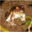

In [ ]:
# In[75]:


img = image.array_to_img(real_images[0] * 255., scale=False)
#img.save(os.path.join(save_dir,'real_frog' + str(step) + '.png'))
img

In [ ]:
# In[53]:


gan.save("gan.h5")

In [ ]:
# In[ ]: